*   Distribution of one variable → histogram
*   Compare categories → bar chart / countplot
*   Spread + outliers → boxplot
*   Relationship between 2 variables → scatterplot
*   All correlations at once → heatmap

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean Titanic (same as Day 2)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["Cabin"])
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Style — makes all charts look clean
sns.set_theme(style="whitegrid")
print("Ready to plot!", df.shape)

Ready to plot! (891, 12)


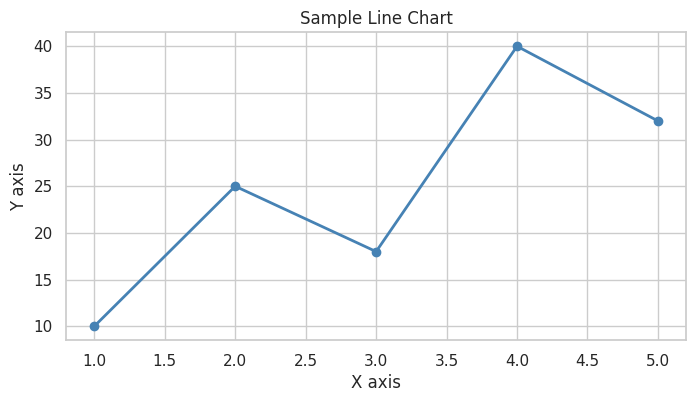

In [2]:
#Line Chart
#LEARNING ONLY
plt.figure(figsize=(8,4)) #creates a canvas 8 inches wide, 4 inches tall
x = [1, 2, 3, 4, 5]
y = [10, 25, 18, 40, 32]
plt.plot(x, y, color="steelblue", marker="o", linewidth=2)
plt.title("Sample Line Chart")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.show()

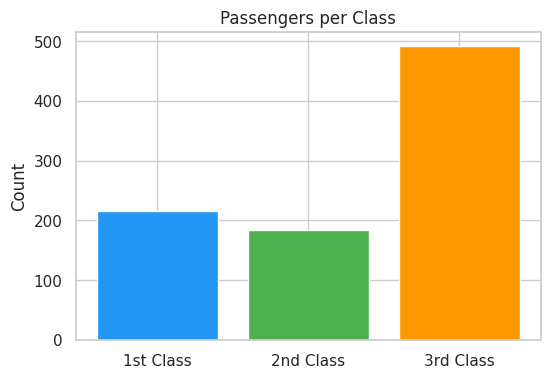

[216 184 491]


In [7]:
# BAR CHART — compare categories
plt.figure(figsize=(6, 4))
classes = ["1st Class", "2nd Class", "3rd Class"]
counts = df["Pclass"].value_counts().sort_index().values
plt.bar(classes, counts, color=["#2196F3", "#4CAF50", "#FF9800"])
plt.title("Passengers per Class")
plt.ylabel("Count")
plt.show()
print(counts)

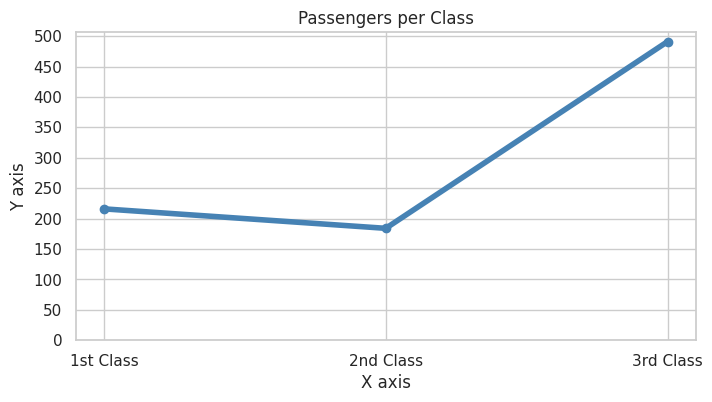

In [19]:
 #line chart for passanger and count
plt.figure(figsize=(8, 4))
classes = ["1st Class", "2nd Class", "3rd Class"]
counts = df["Pclass"].value_counts().sort_index().values
plt.plot(classes, counts, color="steelblue", marker="o", linewidth=4)
plt.title("Passengers per Class")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.yticks(np.arange(0, max(counts) + 10, 50))
# This sets the upper limit for the ticks to max(counts) + 10 =491+10
plt.show()

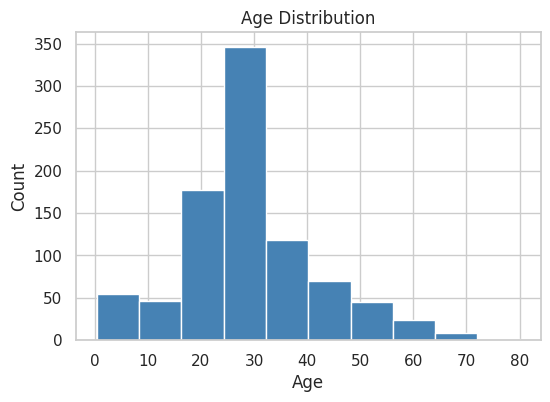

In [20]:
 # HISTOGRAM — shows how data is distributed
plt.figure(figsize=(6, 4))
plt.hist(df["Age"], bins=10, color="steelblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


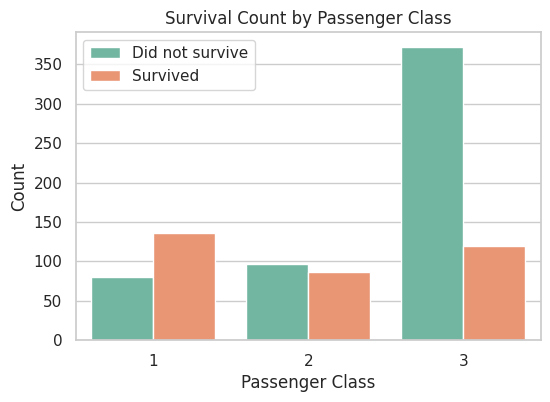

In [21]:
# COUNTPLOT — count of each category
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Pclass", hue="Survived", palette="Set2")
plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.legend(["Did not survive", "Survived"])
plt.show()


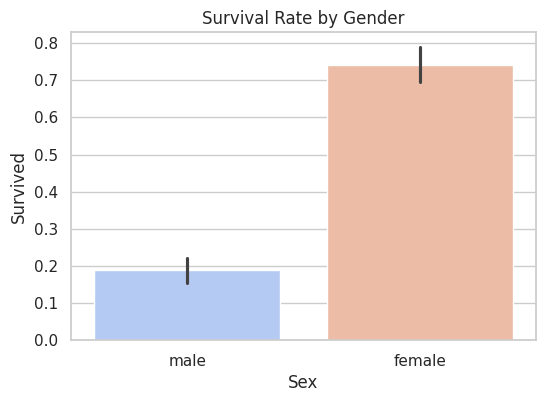

In [32]:
#barplot
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="Sex", y="Survived", hue="Sex", palette="coolwarm")
plt.title("Survival Rate by Gender")
plt.show()

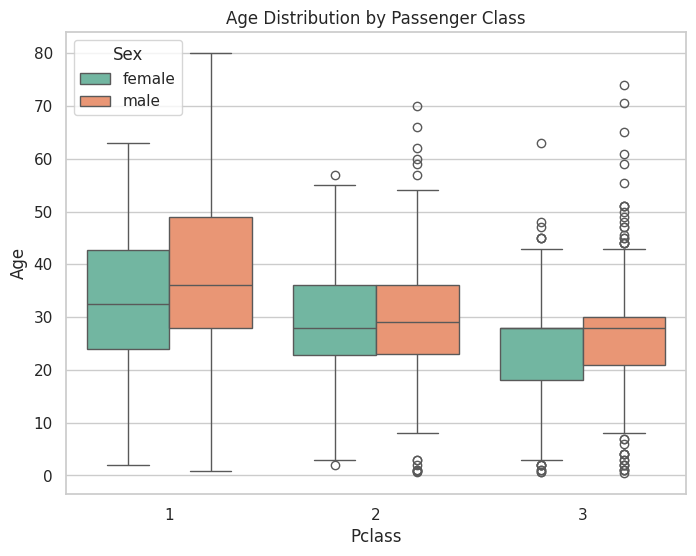

In [40]:
# BOXPLOT — shows median, spread, and outliers
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Pclass', y='Age', hue="Sex",palette="Set2")
plt.title("Age Distribution by Passenger Class")
plt.show()

/tmp/ipykernel_6799/1571555824.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Age',palette="Set2")


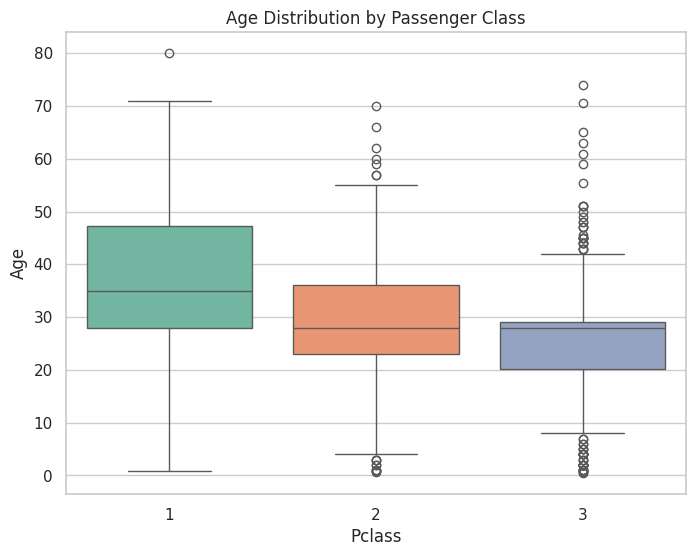

In [41]:
# BOXPLOT — shows median, spread, and outliers
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Pclass', y='Age',palette="Set2")
plt.title("Age Distribution by Passenger Class")
plt.show()

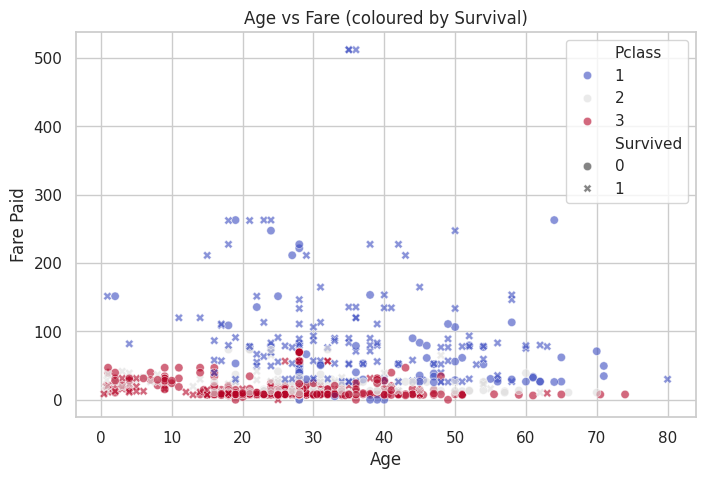

In [44]:
# SCATTERPLOT — relationship between 2 numeric variables
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age", y="Fare",
                hue="Pclass", style="Survived",
                palette="coolwarm", alpha=0.6)
plt.title("Age vs Fare (coloured by Survival)")
plt.xlabel("Age")
plt.ylabel("Fare Paid")
plt.show()

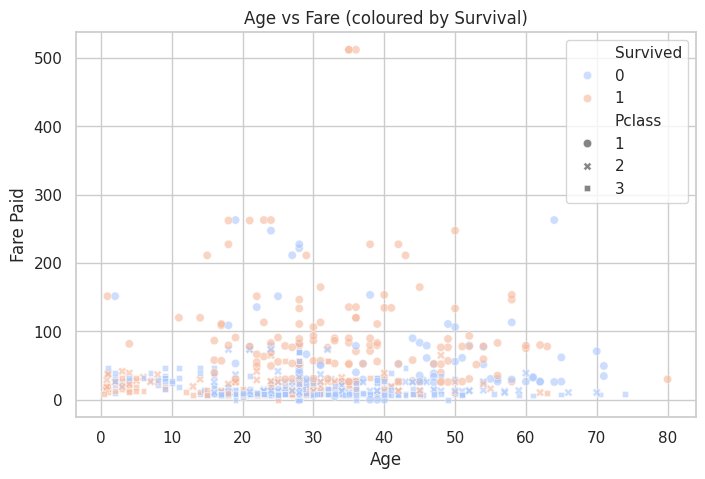

In [45]:
# SCATTERPLOT — relationship between 2 numeric variables
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age", y="Fare",
                hue="Survived", style="Pclass",
                palette="coolwarm", alpha=0.6)
plt.title("Age vs Fare (coloured by Survival)")
plt.xlabel("Age")
plt.ylabel("Fare Paid")
plt.show()

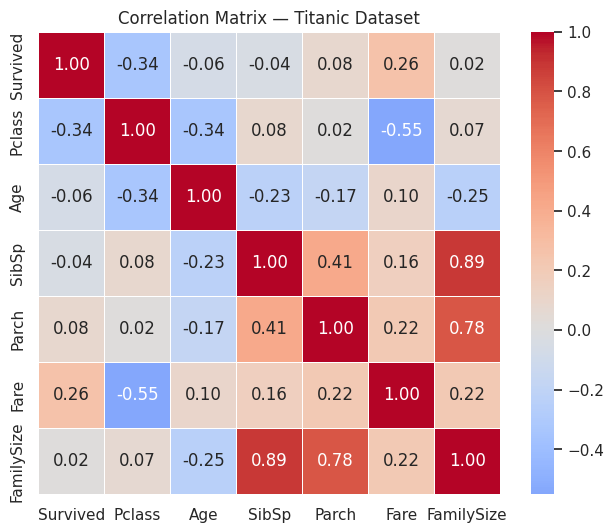

In [48]:
# HEATMAP — shows correlation between all numeric columns
plt.figure(figsize=(8, 6))
numeric_cols = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]]
correlation = numeric_cols.corr()

sns.heatmap(correlation, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Matrix — Titanic Dataset")
plt.show()

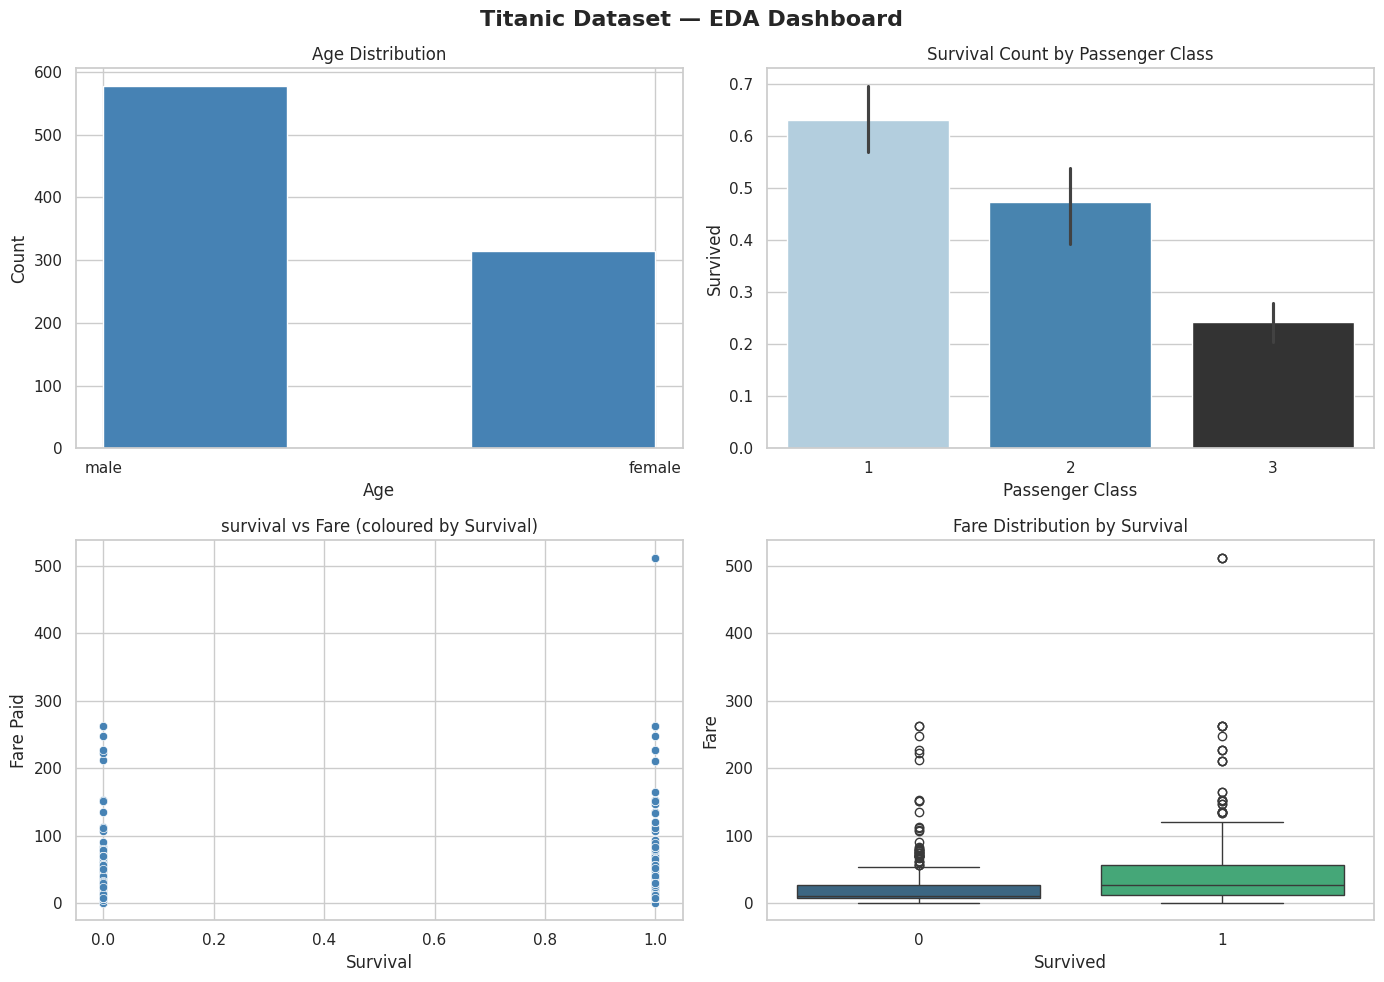

In [69]:
# Put 4 charts in one figure using subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Titanic Dataset — EDA Dashboard", fontsize=16, fontweight="bold")

# Chart 1 — sex distribution
axes[0,0].hist(df['Sex'], bins=3, color='steelblue')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

# Chart 2- Survival by class
sns.barplot(data=df, x='Pclass', y='Survived', hue='Pclass', ax=axes[0,1], palette="Blues_d", legend=False)
axes[0,1].set_title('Survival Count by Passenger Class')
axes[0,1].set_xlabel('Passenger Class')

# Chart 3- Fair and survival
sns.scatterplot(data=df, x='Survived', y='Fare', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('survival vs Fare (coloured by Survival)')
axes[1,0].set_xlabel('Survival')
axes[1,0].set_ylabel('Fare Paid')

# Chart 4 - Fare distribution by Survival (Boxplot)
sns.boxplot(data=df, x='Survived', y='Fare', hue='Survived', ax=axes[1,1], palette='viridis', legend=False)
axes[1,1].set_title('Fare Distribution by Survival')
axes[1,1].set_xlabel('Survived')
axes[1,1].set_ylabel('Fare')
plt.tight_layout()
plt.show()